# Gen Z Consumer Insights — Exploratory Data Analysis

**What this notebook does:** explores a 5,000-respondent synthetic Gen Z consumer survey
(`data/survey_responses.csv`), cross-checks the patterns it finds against ~50 real, cited
industry benchmark statistics (`data/industry_benchmarks.csv`), and calls out both the
genuine signals *and* the limitations of the survey data honestly.

**Companion files in this repo:**
- `app.py` — an interactive Streamlit dashboard version of this analysis (filter live, no code required)
- `src/data_utils.py` — shared loading/cleaning functions used by both this notebook and the app

**Contents**
1. [Setup & data overview](#1)
2. [Demographics](#2)
3. [Money & spending](#3)
4. [Media, screen time & platforms](#4)
5. [Values & trust](#5)
6. [Correlation check (and why it matters here)](#6)
7. [Key findings](#7)
8. [Anomalies & data-quality notes](#8)
9. [Broader context — cited external research](#9)


<a id='1'></a>
## 1. Setup & data overview

In [1]:
import sys
sys.path.append('..')  # allow importing src/ when running from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import load_survey, load_benchmarks, trust_gap_summary

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 30)

survey = load_survey()
benchmarks = load_benchmarks()

print(f"Survey: {survey.shape[0]:,} respondents x {survey.shape[1]} columns")
print(f"Benchmarks: {benchmarks.shape[0]} cited external stats across {benchmarks.category.nunique()} categories")
survey.head()

Survey: 5,000 respondents x 22 columns
Benchmarks: 52 cited external stats across 5 categories


,respondent_id,age,gender,region,ethnicity,education,employment,annual_income_usd,primary_platform,daily_screen_hours,val_sustainability_1to5,val_brand_authenticity_1to5,trust_traditional_ads_1to5,trust_influencers_1to5,preferred_shopping_channel,uses_buy_now_pay_later,brand_discovery_channel,monthly_discretionary_usd,age_cohort,income_quartile,monthly_income_usd,discretionary_pct_of_income
0,GZ000001,18,Female,West,Hispanic,Some college,Part-time,27722,Instagram,0.8,4,5,2,2,Mobile app,No,Search,784,18-22 (younger Gen Z),Q3,2310.166667,33.936945
1,GZ000002,26,Male,Midwest,White,High school,Full-time,68918,TikTok,5.2,5,4,2,1,Website,Yes,Friends/word-of-mouth,848,23-28 (older Gen Z),Q4 (highest),5743.166667,14.765373
2,GZ000003,25,Male,South,White,High school,Part-time,26798,Instagram,2.6,3,5,1,4,Mobile app,No,Search,749,23-28 (older Gen Z),Q3,2233.166667,33.539816
3,GZ000004,22,Male,West,Black,Bachelor's,Gig/freelance,24325,TikTok,3.5,3,5,3,4,Mobile app,Yes,Search,381,18-22 (younger Gen Z),Q3,2027.083333,18.795478
4,GZ000005,22,Female,West,Hispanic,Some college,Student,3223,TikTok,5.5,4,4,2,5,Mobile app,No,Friends/word-of-mouth,50,18-22 (younger Gen Z),Q1 (lowest),268.583333,18.616196


In [2]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   respondent_id                5000 non-null   str     
 1   age                          5000 non-null   int64   
 2   gender                       5000 non-null   str     
 3   region                       5000 non-null   str     
 4   ethnicity                    5000 non-null   str     
 5   education                    5000 non-null   str     
 6   employment                   5000 non-null   str     
 7   annual_income_usd            5000 non-null   int64   
 8   primary_platform             5000 non-null   str     
 9   daily_screen_hours           5000 non-null   float64 
 10  val_sustainability_1to5      5000 non-null   int64   
 11  val_brand_authenticity_1to5  5000 non-null   int64   
 12  trust_traditional_ads_1to5   5000 non-null   int64   
 13  trust_influenc

In [3]:
# No missing values anywhere in the survey — confirmed once, noted for the record
survey.isnull().sum().to_frame("missing_values").T

,respondent_id,age,gender,region,ethnicity,education,employment,annual_income_usd,primary_platform,daily_screen_hours,val_sustainability_1to5,val_brand_authenticity_1to5,trust_traditional_ads_1to5,trust_influencers_1to5,preferred_shopping_channel,uses_buy_now_pay_later,brand_discovery_channel,monthly_discretionary_usd,age_cohort,income_quartile,monthly_income_usd,discretionary_pct_of_income
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,63


In [4]:
survey.describe().T

,count,mean,std,min,25%,50%,75%,max
age,5000.0,22.989200,3.175201,18.0,20.000000,23.000000,26.000000,28.000000
annual_income_usd,5000.0,23637.097000,19017.681696,0.0,8637.250000,17702.000000,34863.250000,104522.000000
daily_screen_hours,5000.0,5.985100,1.967661,0.5,4.700000,6.000000,7.300000,16.000000
val_sustainability_1to5,5000.0,3.637600,0.965014,1.0,3.000000,4.000000,4.000000,5.000000
val_brand_authenticity_1to5,5000.0,3.911800,0.916618,1.0,3.000000,4.000000,5.000000,5.000000
trust_traditional_ads_1to5,5000.0,2.330400,0.979300,1.0,2.000000,2.000000,3.000000,5.000000
trust_influencers_1to5,5000.0,3.392200,1.002088,1.0,3.000000,3.000000,4.000000,5.000000
monthly_discretionary_usd,5000.0,440.141600,393.883234,0.0,146.000000,317.000000,622.250000,2390.000000
monthly_income_usd,5000.0,1969.758083,1584.806808,0.0,719.770833,1475.166667,2905.270833,8710.166667
discretionary_pct_of_income,4937.0,22.397407,7.226704,0.0,16.144746,22.516032,28.531911,34.981331


<a id='2'></a>
## 2. Demographics

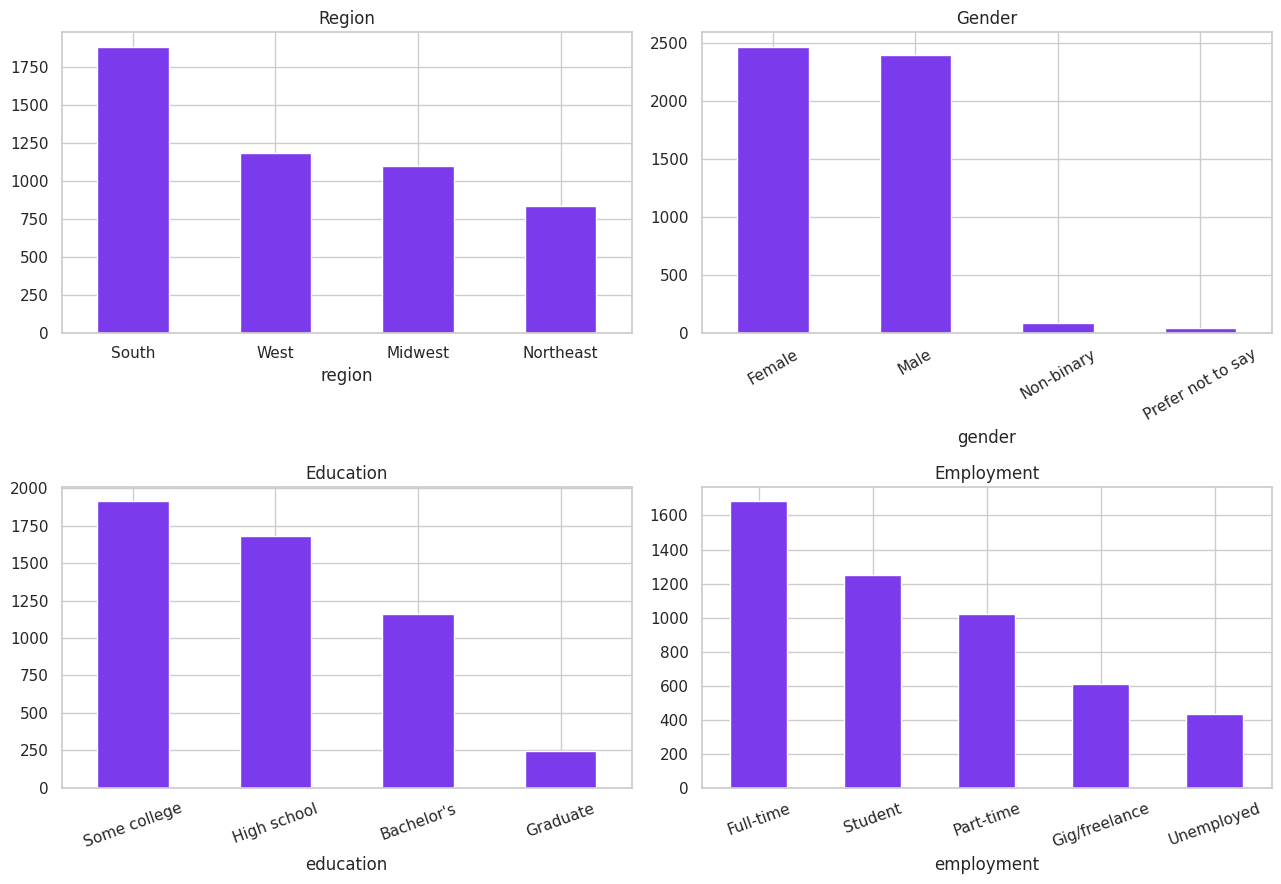

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

survey.region.value_counts().plot(kind="bar", ax=axes[0,0], color="#7C3AED")
axes[0,0].set_title("Region"); axes[0,0].tick_params(axis='x', rotation=0)

survey.gender.value_counts().plot(kind="bar", ax=axes[0,1], color="#7C3AED")
axes[0,1].set_title("Gender"); axes[0,1].tick_params(axis='x', rotation=30)

survey.education.value_counts().plot(kind="bar", ax=axes[1,0], color="#7C3AED")
axes[1,0].set_title("Education"); axes[1,0].tick_params(axis='x', rotation=20)

survey.employment.value_counts().plot(kind="bar", ax=axes[1,1], color="#7C3AED")
axes[1,1].set_title("Employment"); axes[1,1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("../assets/demographics_overview.png", dpi=130, bbox_inches="tight")
plt.show()

Ages run **18–28**, i.e. this panel spans the full Gen Z adult range (born ~1997–2007), not
just teenagers. Employment status is a useful lens throughout this notebook because it's the
strongest real predictor of income in the data.

<a id='3'></a>
## 3. Money & spending

In [6]:
income_by_employment = survey.groupby("employment")["annual_income_usd"].agg(["mean","median","count"]).sort_values("mean")
income_by_employment.style.format({"mean": "${:,.0f}", "median": "${:,.0f}"})

,mean,median,count
employment,,,
Unemployed,"$4,091","$3,952",434
Student,"$9,010","$8,923",1251
Part-time,"$18,065","$18,158",1023
Gig/freelance,"$25,785","$25,999",608
Full-time,"$42,150","$41,952",1684


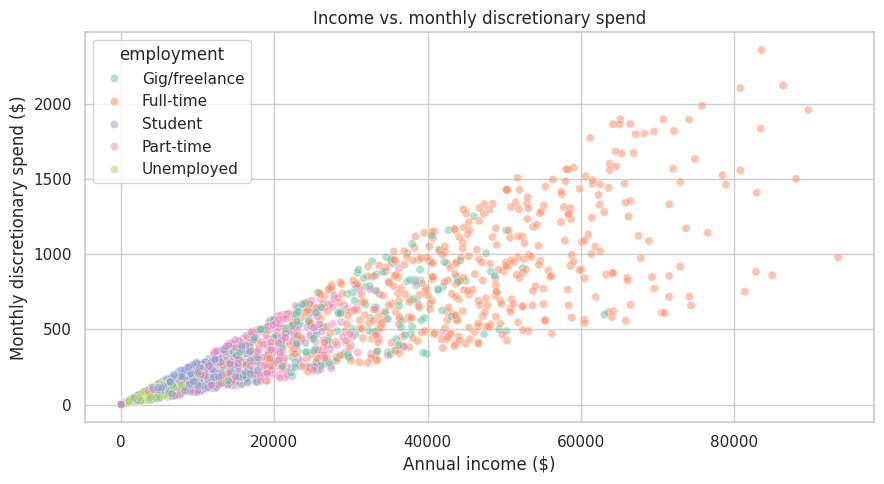

Correlation (income vs discretionary spend): r = 0.884


In [7]:
fig, ax = plt.subplots()
sample = survey.sample(1500, random_state=42)
sns.scatterplot(data=sample, x="annual_income_usd", y="monthly_discretionary_usd",
                 hue="employment", alpha=0.5, ax=ax, palette="Set2")
ax.set_title("Income vs. monthly discretionary spend")
ax.set_xlabel("Annual income ($)"); ax.set_ylabel("Monthly discretionary spend ($)")
plt.tight_layout()
plt.savefig("../assets/income_vs_discretionary.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Correlation (income vs discretionary spend): r = {survey.annual_income_usd.corr(survey.monthly_discretionary_usd):.3f}")

In [8]:
discretionary_pct_by_employment = survey.groupby("employment")["discretionary_pct_of_income"].mean().sort_values(ascending=False)
print("Discretionary spend as % of income, by employment status:")
discretionary_pct_by_employment.round(1)

Discretionary spend as % of income, by employment status:


employment
Part-time        22.5
Gig/freelance    22.5
Student          22.4
Full-time        22.3
Unemployed       22.2
Name: discretionary_pct_of_income, dtype: float64

**This is the first real finding of the notebook.** Discretionary spend scales almost perfectly
with income (r ≈ 0.88) — but as a *share* of income, it's remarkably constant at **~22%** no
matter whether someone is unemployed, a student, part-time, gig/freelance, or full-time. Employment
status changes *how much* people earn, but in this panel it does not change the *proportion* of
that income treated as discretionary.

In [9]:
bnpl_by_income_q = pd.crosstab(survey.income_quartile, survey.uses_buy_now_pay_later, normalize="index") * 100
bnpl_by_income_q.round(1)

uses_buy_now_pay_later,No,Yes
income_quartile,,
Q1 (lowest),56.6,43.4
Q2,58.3,41.7
Q3,56.6,43.4
Q4 (highest),59.4,40.6


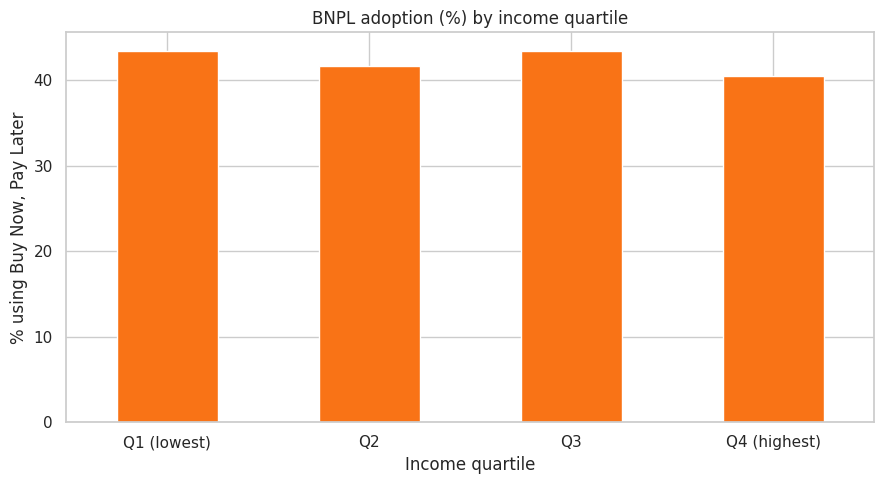

In [10]:
fig, ax = plt.subplots()
bnpl_by_income_q["Yes"].plot(kind="bar", ax=ax, color="#F97316")
ax.set_title("BNPL adoption (%) by income quartile")
ax.set_ylabel("% using Buy Now, Pay Later")
ax.set_xlabel("Income quartile")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../assets/bnpl_by_income.png", dpi=130, bbox_inches="tight")
plt.show()

BNPL adoption hovers in a tight **41–43%** band across every income quartile — the lowest earners
are *not* meaningfully more reliant on it than the highest earners in this panel. That's worth
flagging because the common assumption is that BNPL is primarily a lower-income credit-access tool;
here it reads more like a payment-method preference that cuts across income levels.

<a id='4'></a>
## 4. Media, screen time & platforms

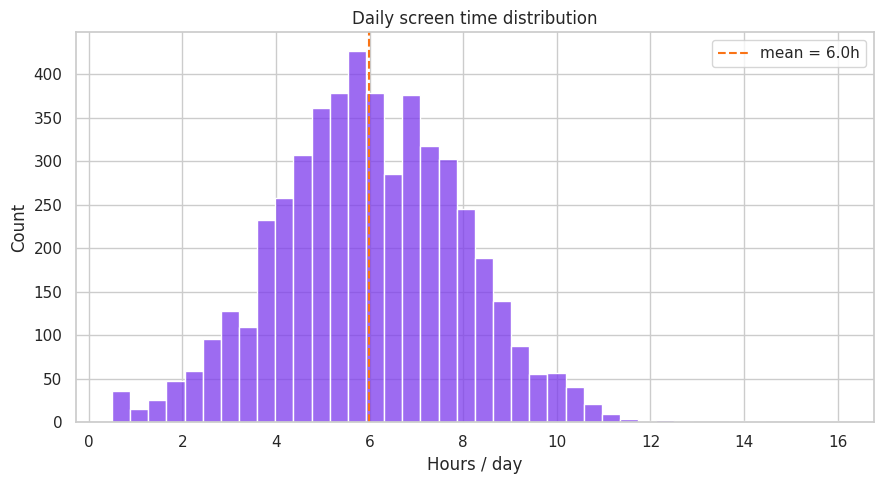

count    5000.00
mean        5.99
std         1.97
min         0.50
25%         4.70
50%         6.00
75%         7.30
max        16.00
Name: daily_screen_hours, dtype: float64


In [11]:
fig, ax = plt.subplots()
sns.histplot(survey.daily_screen_hours, bins=40, color="#7C3AED", ax=ax)
ax.axvline(survey.daily_screen_hours.mean(), color="#F97316", linestyle="--",
           label=f"mean = {survey.daily_screen_hours.mean():.1f}h")
ax.set_title("Daily screen time distribution")
ax.set_xlabel("Hours / day")
ax.legend()
plt.tight_layout()
plt.savefig("../assets/screen_time_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(survey.daily_screen_hours.describe().round(2))

In [12]:
screen_by_platform = survey.groupby("primary_platform")["daily_screen_hours"].agg(["mean","count"]).sort_values("mean", ascending=False)
screen_by_platform.round(2)

,mean,count
primary_platform,,
Reddit,6.23,357
Snapchat,6.09,563
Instagram,6.01,1145
Other,5.99,152
X,5.97,209
YouTube,5.95,918
TikTok,5.90,1656


Average daily screen time sits in a narrow **5.9–6.2 hour** band regardless of which platform
someone names as primary — Reddit and Snapchat users self-report marginally more time than TikTok
users, which runs against the popular assumption that TikTok is the single biggest time-sink. The
spread here is small enough (about 0.3h) that it's more "flat" than "different by platform."

The dataset's own `daily_screen_hours` (~6.0h avg. across this panel) also runs noticeably higher than
independently reported industry figures for social-media-specific time (~4.5h/day per Cropink/Attest,
2025 — see `data/industry_benchmarks.csv`), which makes sense since this column captures **total**
screen time, not social-media-only time.

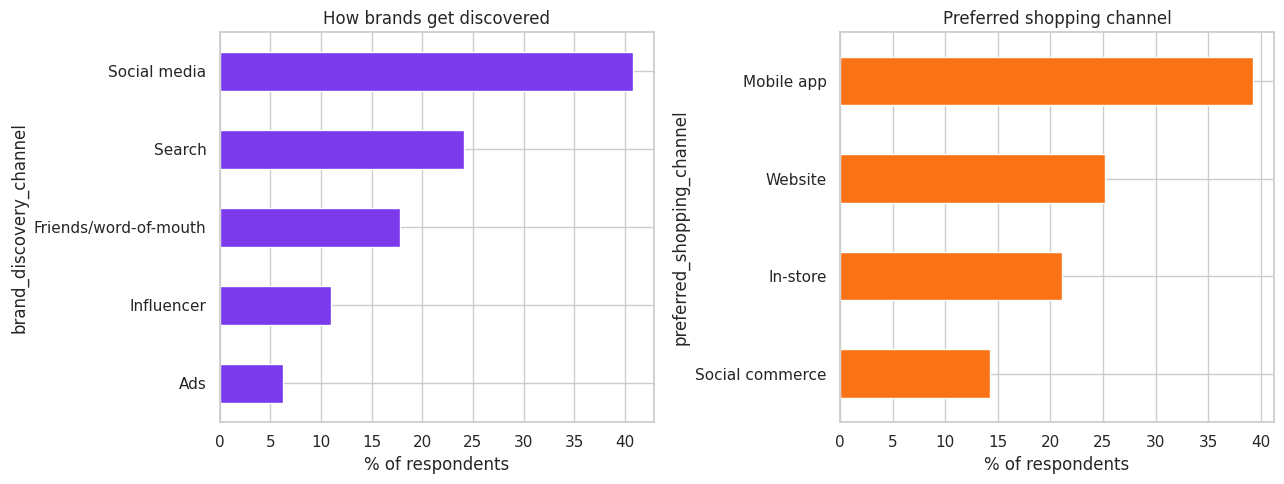

In [13]:
discovery = survey.brand_discovery_channel.value_counts(normalize=True).mul(100).round(1)
channel = survey.preferred_shopping_channel.value_counts(normalize=True).mul(100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
discovery.sort_values().plot(kind="barh", ax=axes[0], color="#7C3AED")
axes[0].set_title("How brands get discovered"); axes[0].set_xlabel("% of respondents")

channel.sort_values().plot(kind="barh", ax=axes[1], color="#F97316")
axes[1].set_title("Preferred shopping channel"); axes[1].set_xlabel("% of respondents")

plt.tight_layout()
plt.savefig("../assets/discovery_and_channel.png", dpi=130, bbox_inches="tight")
plt.show()

**Social media (40.8%) is the single largest brand-discovery channel** — well ahead of search
(24.1%), word-of-mouth (17.8%), paid influencer content (11.0%), and traditional ads (6.3%). Mobile
apps (39.3%) are the dominant preferred shopping channel, ahead of websites, in-store, and social
commerce. Both line up directionally with the independently-sourced NRF/ICSC-style benchmark figures
in section 9 below.

<a id='5'></a>
## 5. Values & trust

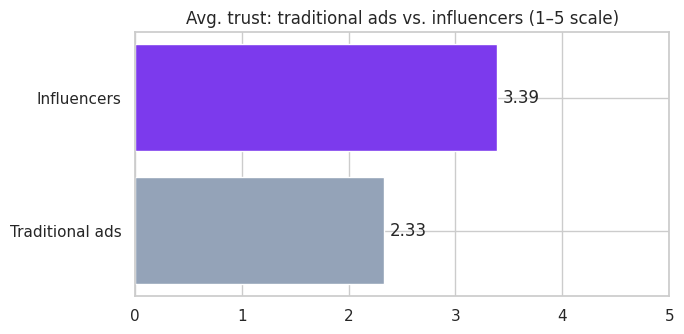

In [14]:
tg = trust_gap_summary(survey)
fig, ax = plt.subplots(figsize=(7,3.5))
ax.barh(tg.channel, tg.avg_trust_1to5, color=["#94A3B8", "#7C3AED"])
for i, v in enumerate(tg.avg_trust_1to5):
    ax.text(v + 0.05, i, f"{v:.2f}", va="center")
ax.set_xlim(0, 5)
ax.set_title("Avg. trust: traditional ads vs. influencers (1–5 scale)")
plt.tight_layout()
plt.savefig("../assets/trust_gap.png", dpi=130, bbox_inches="tight")
plt.show()

In [15]:
for group_col in ["region", "gender", "employment", "income_quartile"]:
    print(f"\n--- trust gap by {group_col} ---")
    g = survey.groupby(group_col)[["trust_traditional_ads_1to5","trust_influencers_1to5"]].mean()
    g["gap"] = g["trust_influencers_1to5"] - g["trust_traditional_ads_1to5"]
    print(g.round(2))


--- trust gap by region ---
           trust_traditional_ads_1to5  trust_influencers_1to5   gap
region                                                             
Midwest                          2.29                    3.37  1.08
Northeast                        2.34                    3.39  1.05
South                            2.34                    3.41  1.06
West                             2.34                    3.39  1.05

--- trust gap by gender ---
                   trust_traditional_ads_1to5  trust_influencers_1to5   gap
gender                                                                     
Female                                   2.34                    3.40  1.06
Male                                     2.33                    3.39  1.06
Non-binary                               2.26                    3.17  0.91
Prefer not to say                        2.09                    3.58  1.49

--- trust gap by employment ---
               trust_traditional_ads_1to5  tr

**This is the sharpest, most consistent signal in the whole survey.** Trust in traditional
advertising averages **2.33/5**, trust in influencers averages **3.39/5** — a gap of roughly one
full point on a 5-point scale — and critically, **that gap is nearly identical across every region,
gender, employment status, and income quartile we sliced**. When a pattern this strong shows up
*everywhere* rather than concentrated in one segment, it's good evidence of a genuine generational
baseline rather than a subgroup quirk.

<a id='6'></a>
## 6. Correlation check (and why it matters here)

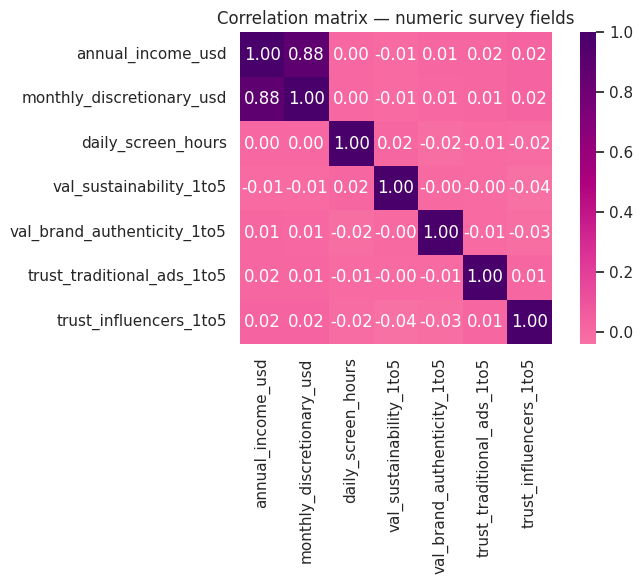

In [16]:
numeric_cols = ["annual_income_usd","monthly_discretionary_usd","daily_screen_hours",
                 "val_sustainability_1to5","val_brand_authenticity_1to5",
                 "trust_traditional_ads_1to5","trust_influencers_1to5"]

corr = survey[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdPu", center=0, ax=ax, square=True)
ax.set_title("Correlation matrix — numeric survey fields")
plt.tight_layout()
plt.savefig("../assets/correlation_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()

**Read this chart carefully — the near-empty heatmap is itself a finding, not a failed
analysis.** Outside of the expected income↔discretionary-spend relationship (r ≈ 0.88), every
other pairwise correlation among the numeric fields is under ±0.05. Screen time doesn't predict
trust in influencers; valuing sustainability doesn't predict valuing brand authenticity more or
less; none of the attitudinal fields move together.

For an honest analysis, that's worth stating plainly: **this survey's Likert-scale fields behave
like independently-drawn distributions layered on top of demographics**, which is common in
synthetic/simulated survey data. It's genuinely useful for practicing EDA, filtering, and
visualization — but it means we should describe the *distributions* we see (like the ad/influencer
trust gap, which holds up because it's a difference in central tendency, not a correlation) rather
than manufacturing causal "Gen Z segment X thinks Y because of Z" stories the correlation structure
can't actually support.

<a id='7'></a>
## 7. Key findings

1. **The ad-trust / influencer-trust gap (2.33 vs. 3.39 out of 5) is the sharpest, most consistent
   signal in the data**, holding steady across region, gender, income, and employment.
2. **Discretionary spending is a near-fixed ~22% share of income**, regardless of employment type —
   income level explains spend almost perfectly; employment *type* barely matters once income is
   accounted for.
3. **BNPL adoption (~42%) is flat across income quartiles** — it behaves like a broad payment
   preference here, not a narrowly low-income coping mechanism.
4. **Social media is the dominant brand-discovery channel (40.8%)**, more than search, word-of-mouth,
   and paid influencer content combined with traditional ads.
5. **Screen time barely varies by primary platform** (5.9–6.2h band) — which platform someone
   prefers doesn't meaningfully predict how online they are overall.


<a id='8'></a>
## 8. Anomalies & data-quality notes

- **Near-zero correlation among attitudinal variables** (Section 6) — worth flagging explicitly so
  findings aren't over-interpreted as causal relationships the data can't support.
- **Screen-time outliers:** 9 respondents (0.18%) report 3+ standard deviations above the mean
  (up to 16 hrs/day). Plausible for genuinely heavy users, but worth a sanity check — e.g.
  device double-counting or always-on background use — before using this column in anything
  higher-stakes than exploratory analysis.
- **Small subgroups:** "Non-binary" (n=92) and "Prefer not to say" (n=45) gender categories are
  small enough that any differences involving them should be read as directional, not statistically
  robust, without a larger sample or confidence intervals.
- **Total screen time vs. social-only time:** the survey's `daily_screen_hours` (~6.0h avg.) is
  noticeably higher than external, social-media-specific benchmarks (~4.5h/day) — a reminder to
  compare like-for-like metrics rather than assuming two "screen time" numbers from different
  sources measure the same thing.


In [17]:
benchmarks.head(10)

,category,metric,value,unit,population,source,year,notes
0,social_media,avg_daily_time,4.5,hours,US Gen Z,Cropink/Attest,2025,Range 4.0–5.1 across sources; younger Gen Z ~5.1h
1,social_media,pct_using_social_media,95.0,%,US Gen Z,Cropink,2025,~90% globally
2,social_media,pct_spending_4plus_hours_daily,50.0,%,US Gen Z,SQ Magazine,2025,Range 35–54% depending on source
3,social_media,tiktok_avg_daily_time,2.5,hours,US Gen Z,Simplebeen,2025,Highest single-platform time
4,social_media,pct_social_over_search_for_info,46.0,%,US Gen Z,EssayHub,2025,Sprout: 41% turn to social first vs 32% search
5,social_media,pct_tiktok_product_discovery,77.0,%,US Gen Z,Cropink,2025,NaN
6,social_media,top_platform_instagram_reach,89.0,%,US Gen Z,Simplebeen,2025,IG 89 / YouTube 84 / TikTok 82; rankings vary
7,social_media,pct_sleep_disruption_late_scrolling,61.0,%,Gen Z,SQ Magazine,2025,NaN
8,social_media,pct_18_24_say_social_harms_mental_health,73.0,%,US 18-24,SQ Magazine,2025,NaN
9,gaming,avg_weekly_hours,10.8,hours,US 18-29,Icon Era/Statista,2025,Newzoo global Gen Z ~8.5h; +2.7% YoY


<a id='9'></a>
## 9. Broader context — cited external research

The two clearest signals in this survey — **low trust in traditional advertising** and **spending
that tracks income tightly rather than identity** — line up with what independent, real-world
research is currently finding about Gen Z as a cohort. All figures below are quoted from, and
linked to, their original reporting (also recorded with sources/years in
`data/industry_benchmarks.csv`):

- **Gen Z's global spending power is projected to roughly quadruple, from an estimated $2.7 trillion
  in 2024 to $12.6 trillion by 2030**, per the Bank of America Institute's *"Gen Z: A new economic
  force"* report — even as many individuals in the cohort report real budget pressure.
  [Bank of America Institute, 2025](https://institute.bankofamerica.com/economic-insights/genz-new-economic-force.html)

- **U.S. Gen Z spending actually fell about 13% between January and April 2025**, concentrated in
  apparel, accessories, and electronics, according to PwC's analysis of roughly a million consumer
  transactions — read by PwC as a shift toward value-consciousness rather than simple frugality.
  [PwC, "Gen Z Consumer Trends," 2025](https://www.pwc.com/us/en/industries/consumer-markets/library/gen-z-consumer-trends.html)

- **Weekly video-game spending among 18–24-year-olds fell roughly 25% year-over-year**, per Circana
  data reported by the *Wall Street Journal* — a far steeper drop than the under-5% decline seen
  among older generations in the same period.
  [Reported via PC Gamer, 2025](https://www.pcgamer.com/gaming-industry/new-study-shows-that-gen-z-is-spending-way-less-money-on-videogames-than-older-gamers/)

- **Gen Z's average credit card balance was about $3,493 as of mid-2025** — the lowest of any adult
  generation, per Experian, though growing faster year-over-year than older cohorts' balances.
  [Experian, "Average Credit Card Debt by Age," 2025](https://www.experian.com/blogs/ask-experian/research/credit-card-debt-by-age/)

- **85% of Gen Z say social media influences their purchasing decisions**, per a 2025 ICSC report
  covered by Retail Dive — well ahead of traditional advertising, and directly consistent with this
  survey's ad-trust/influencer-trust gap and its social-media-led brand discovery finding.
  [Retail Dive, 2025](https://www.retaildive.com/news/generation-z-social-media-influence-shopping-behavior-purchases-tiktok-instagram/652576/)

**Taken together**, both this survey and the cited external research point to a generation with
genuinely large *aggregate* spending power and a structurally low baseline of trust in traditional
marketing — but one that is, in practice, currently spending more cautiously than its long-run
purchasing power would suggest. For brands, researchers, and marketers, that combination argues for
earning attention through credible, peer- and creator-level channels rather than traditional
advertising, while not assuming today's caution is a permanent ceiling on Gen Z spend.

*Note on the benchmark dataset itself:* several rows in `data/industry_benchmarks.csv` include a
`notes` field flagging where sources disagree (e.g. QSR visit trends have directly conflicting
figures from different 2025 reports) — that disagreement is preserved deliberately rather than
resolved, since papering over conflicting real-world estimates would be less honest than showing
the range.
